In [1]:
import numpy as np
import pandas as pd
import GEOparse

from scipy.stats import ttest_ind
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.multitest import multipletests
from sklearn.feature_selection import SelectKBest, f_classif

In [19]:
import logging

logging.getLogger("GEOparse").setLevel(logging.ERROR)

In [ ]:
gse = GEOparse.get_GEO(
    filepath="../data/raw/GSE18123_family.soft"
)

c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (0: SPOT_ID) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


## 1. Dataset Overview

The GSE18123 dataset contains 285 samples measured across two microarray platforms: GPL570 and GPL6244.

For this study, we focus on GPL6244 to maintain a consistent platform for downstream transcriptomic analysis.

In [20]:
print("Number of samples:", len(gse.gsms))
print("Number of platforms:", len(gse.gpls))

Number of samples: 285
Number of platforms: 2


In [21]:
print(gse.gpls.keys())

dict_keys(['GPL570', 'GPL6244'])


In [22]:
# Inspect the number of samples for each platform

platform_counts = {}

for gsm_id, gsm in gse.gsms.items():
    platform = gsm.metadata["platform_id"][0]
    platform_counts[platform] = platform_counts.get(platform, 0) + 1

platform_counts

{'GPL570': 99, 'GPL6244': 186}

In [23]:
# Select samples measured on GPL6244

GPL6244_SAMPLES = [
    gsm_id
    for gsm_id, gsm in gse.gsms.items()
    if gsm.metadata["platform_id"][0] == "GPL6244"
]

print("Number of GPL6244 samples:", len(GPL6244_SAMPLES))
print("First 10 samples:", GPL6244_SAMPLES[:10])

Number of GPL6244 samples: 186
First 10 samples: ['GSM650655', 'GSM650656', 'GSM650657', 'GSM650658', 'GSM650659', 'GSM650660', 'GSM650661', 'GSM650662', 'GSM650663', 'GSM650664']


In [24]:
# Inspect metadata of the first GPL6244 sample

sample_id = GPL6244_SAMPLES[0]

gse.gsms[sample_id].metadata

{'title': ['AC02-1253-01'],
 'geo_accession': ['GSM650655'],
 'status': ['Public on Sep 01 2012'],
 'submission_date': ['Jan 05 2011'],
 'last_update_date': ['Sep 01 2012'],
 'type': ['RNA'],
 'channel_count': ['1'],
 'source_name_ch1': ['Blood'],
 'organism_ch1': ['Homo sapiens'],
 'taxid_ch1': ['9606'],
 'characteristics_ch1': ["diagnosis: ASPERGER'S DISORDER",
  'gender: male',
  'age at blood drawing (months): 156',
  'race: Caucasian',
  'ethnicity: Non-Hispanic',
  'hours (minutes since last caloric intake): : 3:25',
  'chronic diseases: -',
  'allergies: -',
  'developmental/speech disorder: -',
  'neurological disorder: -',
  'psychiatric disorder: -',
  'gastrointestinal disorder: -',
  'autoimmune disorder: -',
  'genetic testing: -',
  'birth defects: -',
  'ct: -',
  'mri: -',
  'medications/vitamin names: ibuprofen, excedrine, multivitamin',
  'cerebral palsy: -',
  'seizure: -',
  'other diseases: -'],
 'molecule_ch1': ['total RNA'],
 'extract_protocol_ch1': ["Trizol extr

## 2. Sample Metadata

Sample-level metadata were extracted from the GEO annotations for the 186 samples measured on GPL6244.

The metadata include diagnostic status, sex, age, and other available clinical characteristics.

In [25]:
import pandas as pd
import re

metadata_rows = []

for sample_id in GPL6244_SAMPLES:
    gsm = gse.gsms[sample_id]
    characteristics = gsm.metadata["characteristics_ch1"]

    row = {
        "sample_id": sample_id,
        "platform": gsm.metadata["platform_id"][0],
        "source": gsm.metadata["source_name_ch1"][0],
    }

    for item in characteristics:
        key, value = item.split(":", 1)
        row[key.strip()] = value.strip()

    metadata_rows.append(row)

metadata = pd.DataFrame(metadata_rows)

print("Metadata shape:", metadata.shape)
metadata.head()

Metadata shape: (186, 24)


,sample_id,platform,source,diagnosis,gender,age at blood drawing (months),race,ethnicity,hours (minutes since last caloric intake),chronic diseases,...,gastrointestinal disorder,autoimmune disorder,genetic testing,birth defects,ct,mri,medications/vitamin names,cerebral palsy,seizure,other diseases
0,GSM650655,GPL6244,Blood,ASPERGER'S DISORDER,male,156,Caucasian,Non-Hispanic,: 3:25,-,...,-,-,-,-,-,-,"ibuprofen, excedrine, multivitamin",-,-,-
1,GSM650656,GPL6244,Blood,AUTISM,male,168,Caucasian,Non-Hispanic,: 0:40,-,...,-,-,-,-,-,-,"Biaxin, Singulair, Lexapro, Biaxin, tylenol, e...",-,-,-
2,GSM650657,GPL6244,Blood,CONTROL,male,228,Black,Non-Hispanic,: 7:35,-,...,-,-,-,-,-,-,tylenol,-,-,-
3,GSM650658,GPL6244,Blood,AUTISM,male,60,Caucasian,Non-Hispanic,: 1:30,-,...,yes,-,-,-,-,-,"OTC cold medications, Risperdal, multivitamin",-,-,-
4,GSM650659,GPL6244,Blood,AUTISM,male,36,Caucasian,Non-Hispanic,: 5:00,-,...,yes,-,-,-,-,-,"pediapops, multivitamin, flouride",-,-,-


In [26]:
print(metadata.columns.tolist())

['sample_id', 'platform', 'source', 'diagnosis', 'gender', 'age at blood drawing (months)', 'race', 'ethnicity', 'hours (minutes since last caloric intake)', 'chronic diseases', 'allergies', 'developmental/speech disorder', 'neurological disorder', 'psychiatric disorder', 'gastrointestinal disorder', 'autoimmune disorder', 'genetic testing', 'birth defects', 'ct', 'mri', 'medications/vitamin names', 'cerebral palsy', 'seizure', 'other diseases']


In [27]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 24 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   sample_id                                  186 non-null    str  
 1   platform                                   186 non-null    str  
 2   source                                     186 non-null    str  
 3   diagnosis                                  186 non-null    str  
 4   gender                                     186 non-null    str  
 5   age at blood drawing (months)              186 non-null    str  
 6   race                                       186 non-null    str  
 7   ethnicity                                  186 non-null    str  
 8   hours (minutes since last caloric intake)  186 non-null    str  
 9   chronic diseases                           183 non-null    str  
 10  allergies                                  186 non-null    st

### Diagnostic Groups

The diagnostic labels were inspected to distinguish ASD subtypes from control samples.

In [29]:
metadata["diagnosis"].value_counts(dropna=False)

diagnosis
CONTROL                82
PDD-NOS                48
AUTISM                 41
ASPERGER'S DISORDER    15
Name: count, dtype: int64

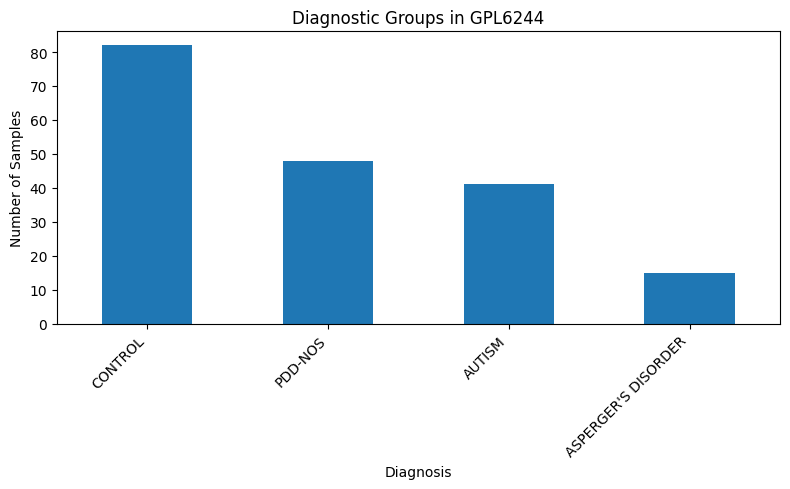

In [30]:
import matplotlib.pyplot as plt

diagnosis_counts = metadata["diagnosis"].value_counts()

plt.figure(figsize=(8, 5))
diagnosis_counts.plot(kind="bar")
plt.title("Diagnostic Groups in GPL6244")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [31]:
metadata["gender"].value_counts(dropna=False)

gender
male      128
female     58
Name: count, dtype: int64

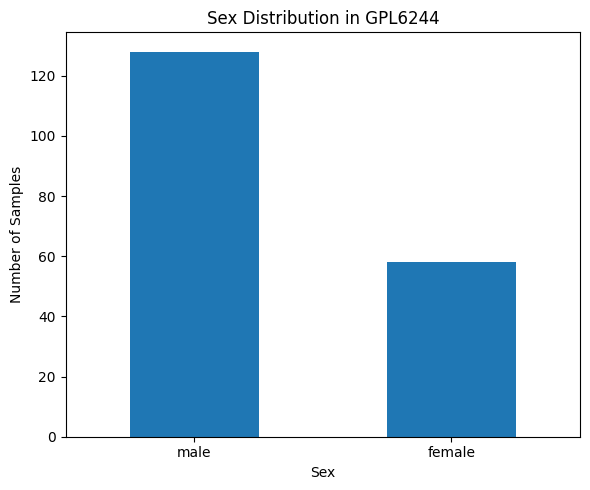

In [32]:
gender_counts = metadata["gender"].value_counts()

plt.figure(figsize=(6, 5))
gender_counts.plot(kind="bar")
plt.title("Sex Distribution in GPL6244")
plt.xlabel("Sex")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
pd.crosstab(
    metadata["diagnosis"],
    metadata["gender"]
)

gender,female,male
diagnosis,,
ASPERGER'S DISORDER,2,13
AUTISM,10,31
CONTROL,34,48
PDD-NOS,12,36


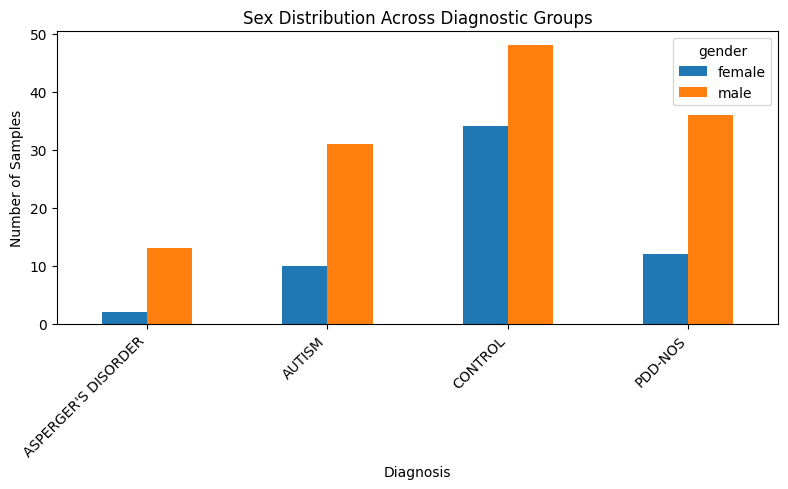

In [34]:
sex_by_diagnosis = pd.crosstab(
    metadata["diagnosis"],
    metadata["gender"]
)

sex_by_diagnosis.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sex Distribution Across Diagnostic Groups")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Binary Diagnostic Group

For binary classification, the three ASD diagnostic subtypes (Autism, Asperger's Disorder, and PDD-NOS) are grouped as ASD, while the control samples are retained as the Control group.

In [35]:
# Create a binary diagnostic label

metadata["group"] = metadata["diagnosis"].apply(
    lambda x: "Control" if x == "CONTROL" else "ASD"
)

metadata["group"].value_counts()

group
ASD        104
Control     82
Name: count, dtype: int64

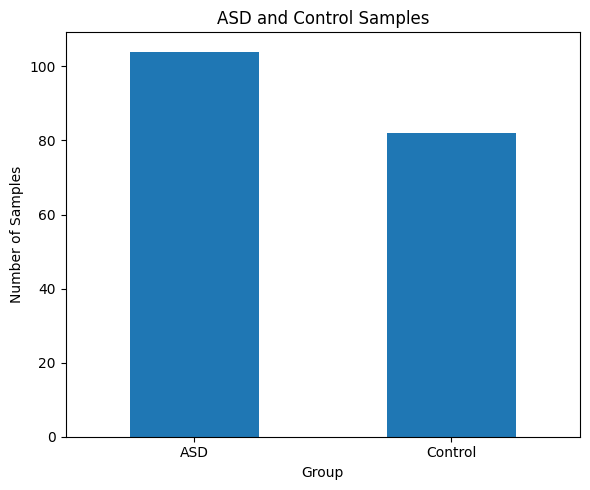

In [36]:
group_counts = metadata["group"].value_counts()

plt.figure(figsize=(6, 5))
group_counts.plot(kind="bar")
plt.title("ASD and Control Samples")
plt.xlabel("Group")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
metadata["age_months"] = pd.to_numeric(
    metadata["age at blood drawing (months)"],
    errors="coerce"
)

metadata["age_months"].describe()

count    186.000000
mean      96.806452
std       52.409460
min       24.000000
25%       51.250000
50%       84.000000
75%      136.500000
max      264.000000
Name: age_months, dtype: float64

In [38]:
print("Missing age:", metadata["age_months"].isna().sum())

Missing age: 0


In [39]:
metadata.groupby("group")["age_months"].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
ASD,104.0,97.096154,48.612300,24.0,60.0,87.5,132.0,252.0
Control,82.0,96.439024,57.168172,24.0,49.0,80.0,144.0,264.0


<Figure size 700x500 with 0 Axes>

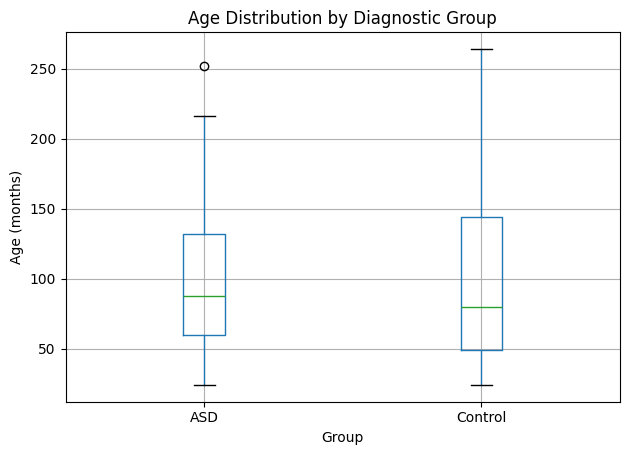

In [40]:
plt.figure(figsize=(7, 5))

metadata.boxplot(
    column="age_months",
    by="group"
)

plt.title("Age Distribution by Diagnostic Group")
plt.suptitle("")
plt.xlabel("Group")
plt.ylabel("Age (months)")
plt.tight_layout()
plt.show()

## 3. Clean Sample Metadata

A cleaned sample-level metadata table was created containing the variables required for downstream analysis, including sample ID, diagnosis, binary diagnostic group, sex, age, and platform.

In [41]:
metadata_clean = metadata[
    [
        "sample_id",
        "diagnosis",
        "group",
        "gender",
        "age_months",
        "platform",
        "source"
    ]
].copy()

metadata_clean.head()

,sample_id,diagnosis,group,gender,age_months,platform,source
0,GSM650655,ASPERGER'S DISORDER,ASD,male,156,GPL6244,Blood
1,GSM650656,AUTISM,ASD,male,168,GPL6244,Blood
2,GSM650657,CONTROL,Control,male,228,GPL6244,Blood
3,GSM650658,AUTISM,ASD,male,60,GPL6244,Blood
4,GSM650659,AUTISM,ASD,male,36,GPL6244,Blood


In [42]:
metadata_clean.shape

(186, 7)

In [43]:
metadata_path = "../data/metadata/sample_metadata.csv"

metadata_clean.to_csv(
    metadata_path,
    index=False
)

print(f"Saved metadata to: {metadata_path}")

Saved metadata to: ../data/metadata/sample_metadata.csv


## 4. Expression Data Extraction

Expression measurements were extracted for the 186 samples profiled on GPL6244.

The resulting matrix will contain probes as rows and samples as columns and will be used as the starting point for downstream preprocessing and feature selection.

In [44]:
# Extract expression tables for GPL6244 samples

expression_tables = []

for sample_id in GPL6244_SAMPLES:
    gsm = gse.gsms[sample_id]
    
    table = gsm.table.copy()
    table["sample_id"] = sample_id
    
    expression_tables.append(table)

print(f"Number of expression tables: {len(expression_tables)}")

Number of expression tables: 186


In [46]:
expression_tables[0].head()

,ID_REF,VALUE,sample_id
0,7892501,9.67160,GSM650655
1,7892502,122.91175,GSM650655
2,7892503,151.17249,GSM650655
3,7892504,1935.89058,GSM650655
4,7892505,21.14810,GSM650655


In [47]:
expression_tables[0].columns.tolist()

['ID_REF', 'VALUE', 'sample_id']

In [48]:
# Build probe × sample expression matrix

expression_matrix = pd.concat(
    [
        table.set_index("ID_REF")["VALUE"].rename(sample_id)
        for table, sample_id in zip(expression_tables, GPL6244_SAMPLES)
    ],
    axis=1
)

print("Expression matrix shape:", expression_matrix.shape)
expression_matrix.head()

Expression matrix shape: (33297, 186)


,GSM650655,GSM650656,GSM650657,GSM650658,GSM650659,GSM650660,GSM650661,GSM650662,GSM650663,GSM650664,...,GSM650944,GSM650946,GSM650950,GSM650951,GSM650954,GSM650959,GSM650968,GSM650969,GSM650970,GSM650975
ID_REF,,,,,,,,,,,,,,,,,,,,,
7892501,9.67160,79.14403,5.01300,25.72981,13.91895,50.35127,0.00710,21.05778,17.47698,21.28318,...,3.29406,11.12443,10.39181,8.97071,10.81198,4.68356,6.86785,17.74369,25.06523,0.20273
7892502,122.91175,104.38295,72.69745,145.16537,135.98053,175.38919,76.26821,132.59755,71.81705,111.28992,...,91.05885,111.46063,122.56646,114.05913,118.40833,108.89500,116.92853,81.63403,125.67404,162.58068
7892503,151.17249,67.21808,121.55192,95.46856,142.72005,139.20885,76.43104,129.48506,28.21930,117.98628,...,68.07263,33.71550,37.54560,55.18136,51.72213,43.75254,39.59656,53.28886,52.58810,41.59902
7892504,1935.89058,1302.83223,2160.06200,1962.15620,2244.96492,1881.05895,1872.58446,2172.58165,1855.87522,2178.26544,...,911.73272,938.98578,966.40733,968.54483,952.49003,1265.23364,1218.08127,1268.45347,1394.62097,1005.47667
7892505,21.14810,13.81453,23.37327,21.44558,20.51383,34.54137,21.32496,20.20900,18.05306,31.27404,...,19.42496,12.85209,16.61253,22.24478,21.30586,14.24507,18.37833,20.56806,21.40529,17.12014


In [49]:
print(
    "Total missing values:",
    expression_matrix.isna().sum().sum()
)

Total missing values: 0


In [50]:
print(
    "Duplicated probe IDs:",
    expression_matrix.index.duplicated().sum()
)

Duplicated probe IDs: 0


In [51]:
expression_matrix.dtypes.value_counts()

float64    186
Name: count, dtype: int64

In [52]:
expression_matrix.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
GSM650655,33297.0,355.714150,904.134076,0.00044,46.90279,119.69605,306.81613,21551.26666
GSM650656,33297.0,368.801310,928.983572,0.00045,46.49345,114.83118,312.02414,20878.30615
GSM650657,33297.0,336.702424,883.373264,0.00044,63.81039,132.38325,281.42850,25155.54134
GSM650658,33297.0,369.290563,927.125834,0.00033,62.18270,138.46939,317.51090,22004.19270
GSM650659,33297.0,359.086663,908.202135,0.00044,56.64695,130.98528,306.95448,22271.17774


### Expression Distribution Across Samples

The distribution of expression values was examined across samples to identify major differences in overall signal intensity and potential technical outliers.

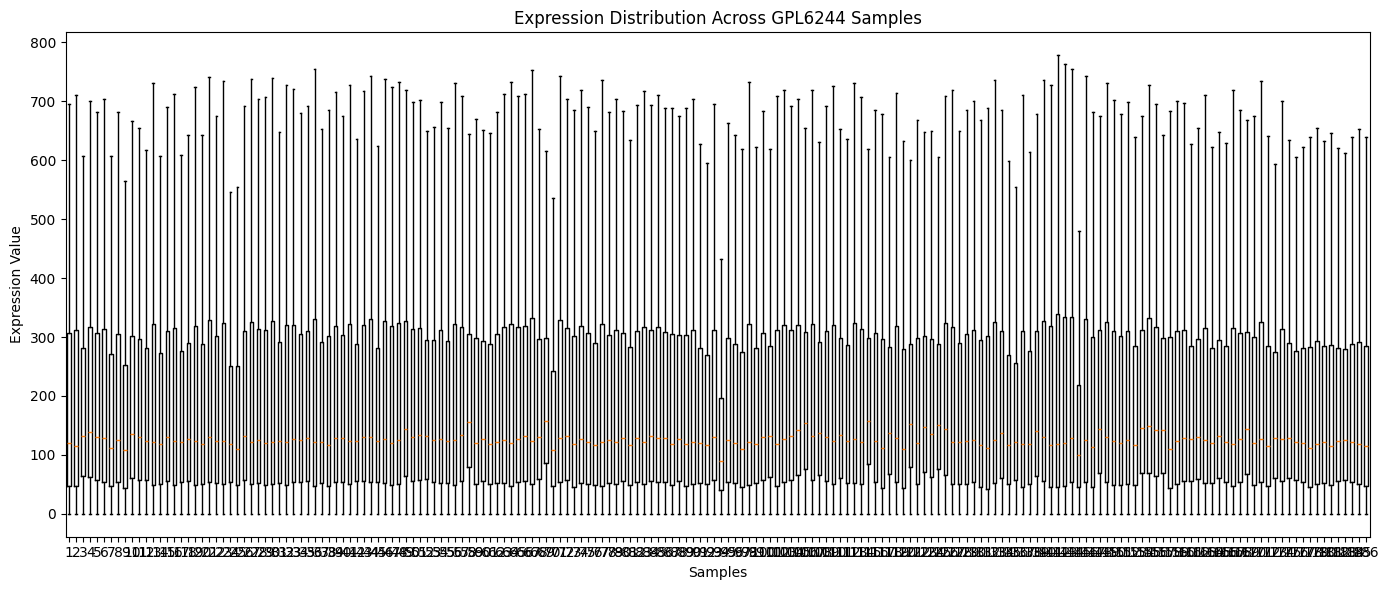

In [54]:
plt.figure(figsize=(14, 6))

plt.boxplot(
    expression_matrix.values,
    showfliers=False
)

plt.title("Expression Distribution Across GPL6244 Samples")
plt.xlabel("Samples")
plt.ylabel("Expression Value")

plt.tight_layout()
plt.show()

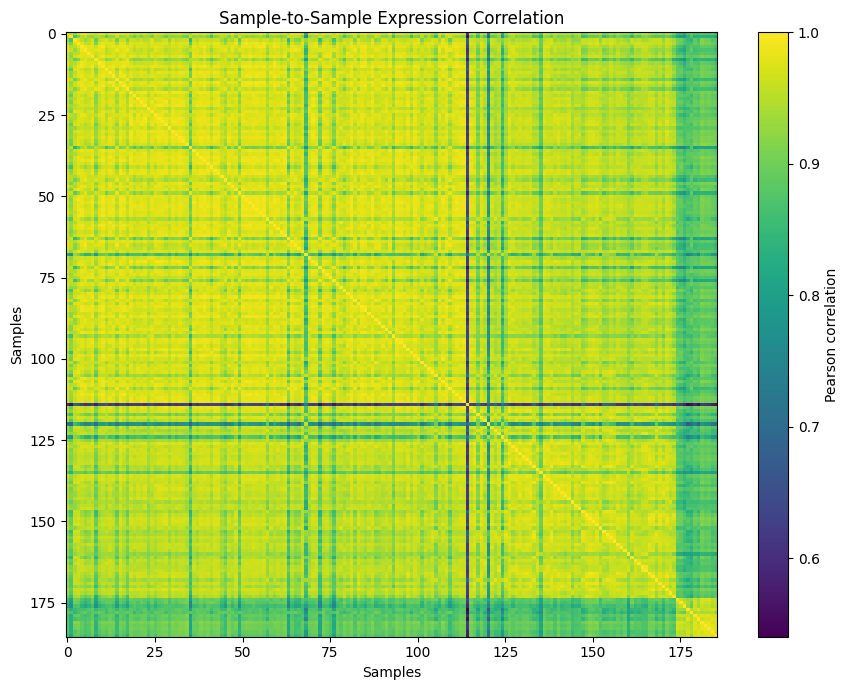

In [55]:
sample_correlation = expression_matrix.corr()

plt.figure(figsize=(9, 7))

plt.imshow(
    sample_correlation,
    aspect="auto"
)

plt.colorbar(label="Pearson correlation")
plt.title("Sample-to-Sample Expression Correlation")
plt.xlabel("Samples")
plt.ylabel("Samples")

plt.tight_layout()
plt.show()

## Probe Annotation and Gene Mapping

The expression matrix contains probe-level measurements from the Affymetrix Human Gene 1.0 ST Array (GPL6244).

Before downstream statistical analysis and machine learning, probes need to be mapped to gene identifiers. This step is important because multiple probes may correspond to the same gene, and some probes may not have a valid gene annotation.

We therefore first inspect the GPL6244 platform annotation and determine which identifiers are available for mapping probes to genes.

In [56]:
platform = gse.gpls["GPL6244"]

print(platform.table.shape)
print(platform.table.columns.tolist())

(33297, 12)
['ID', 'GB_LIST', 'SPOT_ID', 'seqname', 'RANGE_GB', 'RANGE_STRAND', 'RANGE_START', 'RANGE_STOP', 'total_probes', 'gene_assignment', 'mrna_assignment', 'category']


## Inspecting Probe-to-Gene Annotation

The GPL6244 platform annotation provides a `gene_assignment` field for each probe. We inspect representative entries to determine the annotation format before performing probe-to-gene mapping.

In [57]:
annotation = platform.table.copy()

annotation[["ID", "gene_assignment", "mrna_assignment", "category"]].head(10)

,ID,gene_assignment,mrna_assignment,category
0,7896736,---,NONHSAT060105 // NONCODE // Non-coding transcr...,main
1,7896738,ENST00000328113 // OR4G2P // olfactory recepto...,ENST00000328113 // ENSEMBL // havana:known chr...,main
2,7896740,"NM_001004195 // OR4F4 // olfactory receptor, f...",NM_001004195 // RefSeq // Homo sapiens olfacto...,main
3,7896742,NR_024437 // LOC728323 // uncharacterized LOC7...,NR_024437 // RefSeq // Homo sapiens uncharacte...,main
4,7896744,"NM_001005221 // OR4F29 // olfactory receptor, ...",NM_001005221 // RefSeq // Homo sapiens olfacto...,main
5,7896746,ENST00000387377 // MT-TM // mitochondrially en...,ENST00000387377 // ENSEMBL // mt_genbank_impor...,main
6,7896748,ENST00000387382 // MT-TW // mitochondrially en...,ENST00000387382 // ENSEMBL // mt_genbank_impor...,main
7,7896750,ENST00000387419 // MT-TD // mitochondrially en...,ENST00000387419 // ENSEMBL // mt_genbank_impor...,main
8,7896752,ENST00000387421 // MT-TK // mitochondrially en...,ENST00000387421 // ENSEMBL // mt_genbank_impor...,main
9,7896754,ENST00000540997 // LOC100287497 // uncharacter...,ENST00000540997 // ENSEMBL // havana:known chr...,main


In [58]:
annotation["gene_assignment"].head(20).tolist()

['---',
 'ENST00000328113 // OR4G2P // olfactory receptor, family 4, subfamily G, member 2 pseudogene // --- // --- /// ENST00000492842 // OR4G11P // olfactory receptor, family 4, subfamily G, member 11 pseudogene // --- // --- /// ENST00000588632 // OR4G1P // olfactory receptor, family 4, subfamily G, member 1 pseudogene // --- // ---',
 'NM_001004195 // OR4F4 // olfactory receptor, family 4, subfamily F, member 4 // 15q26.3 // 26682 /// NM_001005240 // OR4F17 // olfactory receptor, family 4, subfamily F, member 17 // 19p13.3 // 81099 /// NM_001005484 // OR4F5 // olfactory receptor, family 4, subfamily F, member 5 // 1p36.33 // 79501 /// ENST00000318050 // OR4F17 // olfactory receptor, family 4, subfamily F, member 17 // 19p13.3 // 81099 /// ENST00000326183 // OR4F4 // olfactory receptor, family 4, subfamily F, member 4 // 15q26.3 // 26682 /// ENST00000335137 // OR4F5 // olfactory receptor, family 4, subfamily F, member 5 // 1p36.33 // 79501 /// ENST00000585993 // OR4F17 // olfactory 

## Assessing Probe Annotation Ambiguity

A probe may be annotated to multiple transcripts or genes. To avoid assigning an expression measurement to an incorrect gene, probes with ambiguous mappings to multiple distinct gene symbols will be excluded from the primary gene-level analysis.

First, we quantify the extent of missing and ambiguous gene annotation.

In [59]:
def extract_gene_symbols(annotation_string):
    if pd.isna(annotation_string) or annotation_string == "---":
        return []
    
    records = annotation_string.split(" /// ")
    gene_symbols = []
    
    for record in records:
        fields = [field.strip() for field in record.split(" // ")]
        
        if len(fields) >= 2:
            gene_symbol = fields[1]
            
            if gene_symbol not in {"---", ""}:
                gene_symbols.append(gene_symbol)
    
    return sorted(set(gene_symbols))


annotation["gene_symbols"] = annotation["gene_assignment"].apply(
    extract_gene_symbols
)

annotation["n_gene_symbols"] = annotation["gene_symbols"].apply(len)

print("Total probes:", len(annotation))
print("Probes with no gene annotation:", (annotation["n_gene_symbols"] == 0).sum())
print("Probes mapped to exactly one gene:", (annotation["n_gene_symbols"] == 1).sum())
print("Probes mapped to multiple genes:", (annotation["n_gene_symbols"] > 1).sum())

Total probes: 33297
Probes with no gene annotation: 8004
Probes mapped to exactly one gene: 22153
Probes mapped to multiple genes: 3140


In [60]:
annotation.loc[
    annotation["n_gene_symbols"] > 1,
    ["ID", "gene_symbols"]
].head(10)

,ID,gene_symbols
1,7896738,"[OR4G11P, OR4G1P, OR4G2P]"
2,7896740,"[OR4F17, OR4F4, OR4F5]"
3,7896742,"[LINC00266-1, LINC00266-2P, LINC00266-3, LINC0..."
4,7896744,"[OR4F16, OR4F1P, OR4F21, OR4F28P, OR4F29, OR4F..."
9,7896754,"[LOC100287497, LOC100287934, LOC101930657]"
10,7896756,"[FAM87A, FAM87B]"
27,7896937,"[ATAD3A, ATAD3B, ATAD3C]"
28,7896952,"[ATAD3A, ATAD3B]"
29,7896961,"[ATAD3A, ATAD3B, ATAD3C]"
32,7897006,"[MMP23A, MMP23B]"


## Filtering to Unambiguous Probe-to-Gene Mappings

For the primary analysis, we retain only probes that map unambiguously to a single gene symbol.

Probes without a gene annotation and probes mapped to multiple distinct genes are excluded from the primary gene-level analysis. This conservative strategy reduces the risk of assigning a probe expression profile to the wrong gene.

In [61]:
unambiguous_annotation = annotation[
    annotation["n_gene_symbols"] == 1
].copy()

unambiguous_annotation["gene_symbol"] = (
    unambiguous_annotation["gene_symbols"].str[0]
)

print("Unambiguous probes:", len(unambiguous_annotation))
print(
    "Unique genes represented:",
    unambiguous_annotation["gene_symbol"].nunique()
)

Unambiguous probes: 22153
Unique genes represented: 21408


In [62]:
unambiguous_annotation[
    ["ID", "gene_symbol"]
].head(10)

,ID,gene_symbol
5,7896746,MT-TM
6,7896748,MT-TW
7,7896750,MT-TD
8,7896752,MT-TK
11,7896759,LINC01128
12,7896761,SAMD11
13,7896779,KLHL17
14,7896798,PLEKHN1
15,7896817,ISG15
16,7896822,AGRN


In [63]:
probe_counts_per_gene = (
    unambiguous_annotation["gene_symbol"]
    .value_counts()
)

print("Genes with one probe:", (probe_counts_per_gene == 1).sum())
print("Genes with multiple probes:", (probe_counts_per_gene > 1).sum())
print("Maximum probes for one gene:", probe_counts_per_gene.max())

Genes with one probe: 20833
Genes with multiple probes: 575
Maximum probes for one gene: 26


## Aggregating Multiple Probes at the Gene Level

After restricting the analysis to unambiguous probe-to-gene mappings, multiple probes may still represent the same gene.

To obtain one expression feature per gene, expression values from probes targeting the same gene are aggregated using the median across probes. The median is a robust summary that reduces the influence of unusually high or low probe-level measurements.

This produces a gene-level expression matrix suitable for downstream statistical analysis and machine learning.

In [64]:
# Keep only probes with an unambiguous gene mapping
probe_expression = expression_matrix.loc[
    unambiguous_annotation["ID"]
].copy()

# Replace probe IDs with gene symbols
probe_expression["gene_symbol"] = (
    unambiguous_annotation
    .set_index("ID")
    .loc[probe_expression.index, "gene_symbol"]
)

# Aggregate multiple probes belonging to the same gene
gene_expression = (
    probe_expression
    .drop(columns="gene_symbol")
    .groupby(probe_expression["gene_symbol"])
    .median()
)

print("Gene-level expression matrix shape:", gene_expression.shape)

Gene-level expression matrix shape: (21408, 186)


In [65]:
print("Number of genes:", gene_expression.shape[0])
print("Number of samples:", gene_expression.shape[1])
print("Missing values:", gene_expression.isna().sum().sum())

Number of genes: 21408
Number of samples: 186
Missing values: 0


## Assessing the Gene-Level Expression Scale

The GPL6244 expression data were processed using the Probe Logarithmic Intensity Error (PLIER) method. Therefore, an additional log transformation should not be applied without first examining the distribution and numerical scale of the resulting gene-level expression matrix.

We inspect summary statistics and the distribution of gene-level expression values to determine whether an additional transformation is appropriate.

In [66]:
print("Minimum:", gene_expression.min().min())
print("Maximum:", gene_expression.max().max())
print("Median:", gene_expression.median().median())
print("Mean:", gene_expression.mean().mean())

Minimum: 0.00024
Maximum: 167654.0977
Median: 127.0873075
Mean: 258.33359687946023


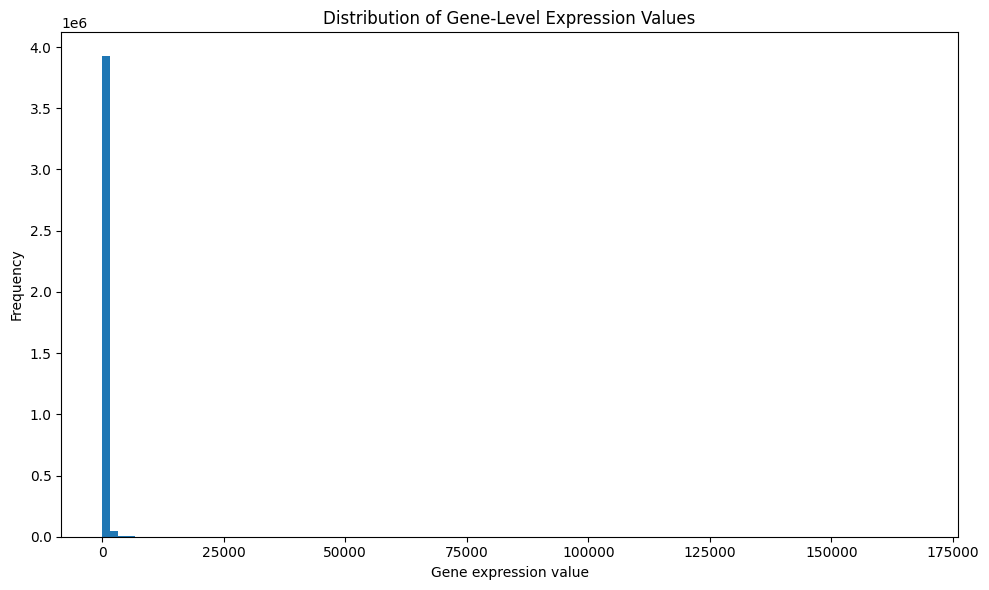

In [67]:
plt.figure(figsize=(10, 6))

plt.hist(
    gene_expression.values.flatten(),
    bins=100
)

plt.xlabel("Gene expression value")
plt.ylabel("Frequency")
plt.title("Distribution of Gene-Level Expression Values")

plt.tight_layout()
plt.show()

## Inspecting Expression Distribution on a Logarithmic Scale

The gene-level expression values show a strongly right-skewed distribution, with a median of approximately 127 and a maximum above 167,000.

Because the dataset was already processed using PLIER, the original expression matrix will not be transformed at this stage. Instead, a log2-transformed copy is used only for visualization to better assess the overall distribution.

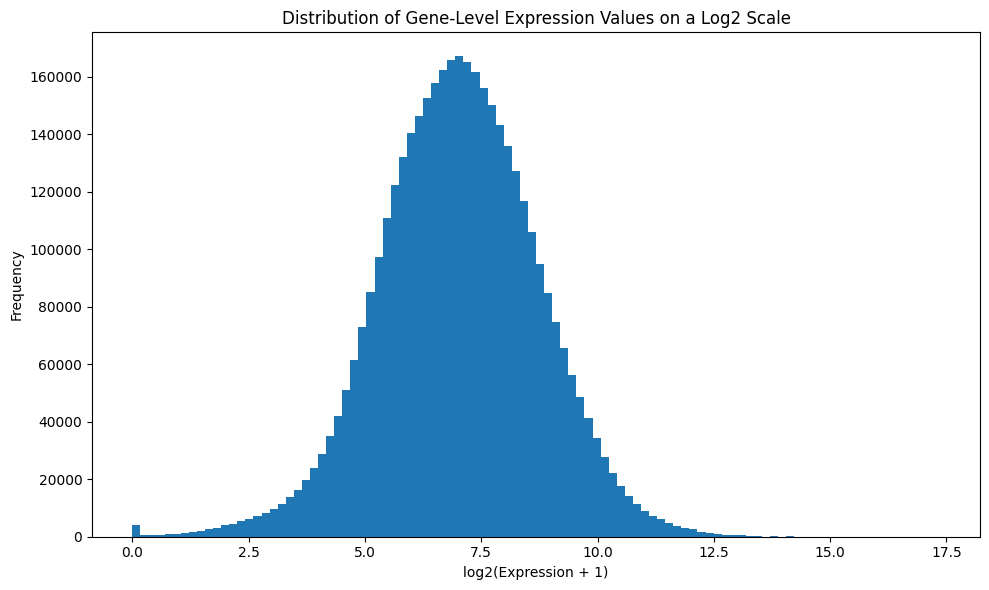

In [68]:
gene_expression_log2 = np.log2(gene_expression + 1)

plt.figure(figsize=(10, 6))

plt.hist(
    gene_expression_log2.values.flatten(),
    bins=100
)

plt.xlabel("log2(Expression + 1)")
plt.ylabel("Frequency")
plt.title("Distribution of Gene-Level Expression Values on a Log2 Scale")

plt.tight_layout()
plt.show()

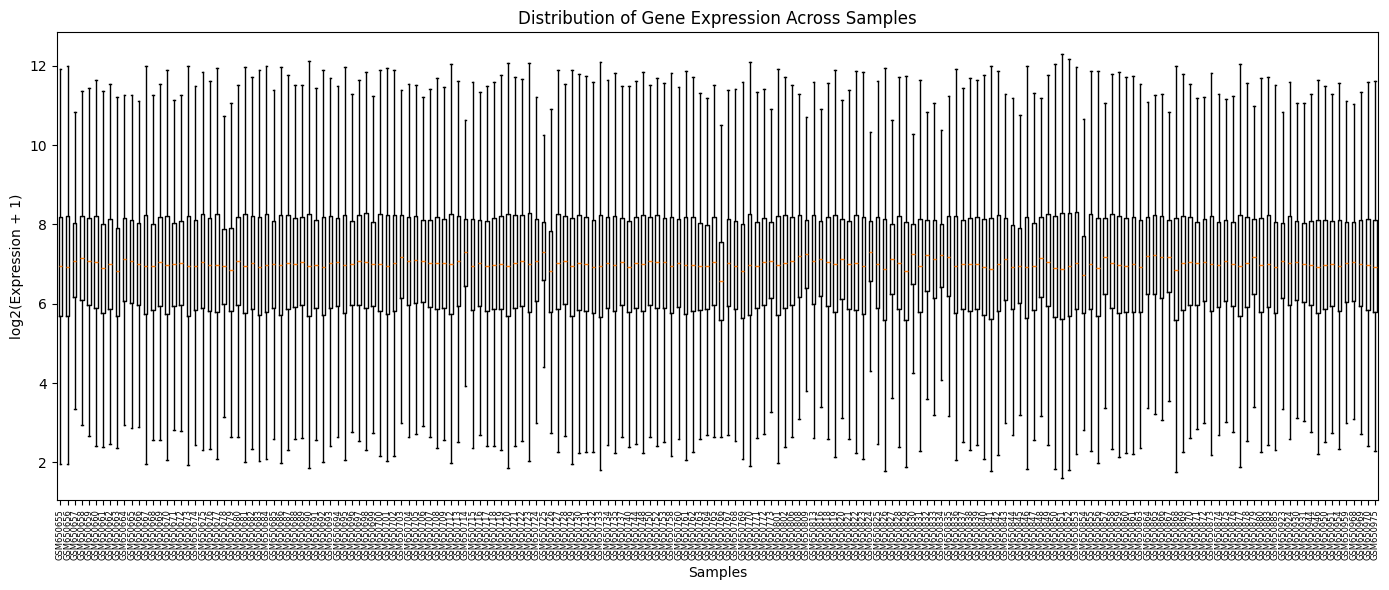

In [69]:
plt.figure(figsize=(14, 6))

plt.boxplot(
    gene_expression_log2.values,
    showfliers=False
)

plt.xlabel("Samples")
plt.ylabel("log2(Expression + 1)")
plt.title("Distribution of Gene Expression Across Samples")
plt.xticks(
    ticks=np.arange(1, len(gene_expression_log2.columns) + 1),
    labels=gene_expression_log2.columns,
    rotation=90,
    fontsize=6
)

plt.tight_layout()
plt.show()

In [70]:
sample_qc = pd.DataFrame({
    "median": gene_expression_log2.median(axis=0),
    "mean": gene_expression_log2.mean(axis=0),
    "std": gene_expression_log2.std(axis=0),
    "q1": gene_expression_log2.quantile(0.25, axis=0),
    "q3": gene_expression_log2.quantile(0.75, axis=0)
})

sample_qc["IQR"] = sample_qc["q3"] - sample_qc["q1"]

sample_qc.sort_values("median")

,median,mean,std,q1,q3,IQR
GSM650766,6.575931,6.547754,1.666764,5.592481,7.558672,1.966191
GSM650854,6.731452,6.695373,1.675696,5.756579,7.712874,1.956295
GSM650829,6.823384,6.781519,1.899023,5.585260,8.049471,2.464211
GSM650663,6.827456,6.770556,1.714318,5.686874,7.899419,2.212545
GSM650769,6.832801,6.804517,1.805089,5.642584,8.019688,2.377105
...,...,...,...,...,...,...
GSM650809,7.258976,7.252863,1.411919,6.391423,8.119063,1.727640
GSM650830,7.261706,7.223386,1.354404,6.503205,8.010377,1.507172
GSM650714,7.291272,7.281232,1.407681,6.448108,8.124804,1.676696
GSM650725,7.304697,7.312908,1.314433,6.593095,8.059298,1.466202


In [71]:
print("Median range:")
print(sample_qc["median"].min(), "to", sample_qc["median"].max())

print("\nIQR range:")
print(sample_qc["IQR"].min(), "to", sample_qc["IQR"].max())

Median range:
6.575930668684436 to 7.304716686515855

IQR range:
1.4662021704250714 to 2.6870452089514156


In [72]:
print("Lowest median samples:")
print(sample_qc.nsmallest(5, "median"))

print("\nHighest median samples:")
print(sample_qc.nlargest(5, "median"))

Lowest median samples:
             median      mean       std        q1        q3       IQR
GSM650766  6.575931  6.547754  1.666764  5.592481  7.558672  1.966191
GSM650854  6.731452  6.695373  1.675696  5.756579  7.712874  1.956295
GSM650829  6.823384  6.781519  1.899023  5.585260  8.049471  2.464211
GSM650663  6.827456  6.770556  1.714318  5.686874  7.899419  2.212545
GSM650769  6.832801  6.804517  1.805089  5.642584  8.019688  2.377105

Highest median samples:
             median      mean       std        q1        q3       IQR
GSM650824  7.304717  7.314305  1.314593  6.569751  8.075561  1.505810
GSM650725  7.304697  7.312908  1.314433  6.593095  8.059298  1.466202
GSM650714  7.291272  7.281232  1.407681  6.448108  8.124804  1.676696
GSM650830  7.261706  7.223386  1.354404  6.503205  8.010377  1.507172
GSM650809  7.258976  7.252863  1.411919  6.391423  8.119063  1.727640


In [73]:
from sklearn.decomposition import PCA

# Samples × genes
X_pca = gene_expression_log2.T

pca = PCA(n_components=10)
X_pca_result = pca.fit_transform(X_pca)

explained_variance = pca.explained_variance_ratio_

print("Explained variance by first 10 PCs:")
for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance:.4f} ({variance * 100:.2f}%)")

Explained variance by first 10 PCs:
PC1: 0.2902 (29.02%)
PC2: 0.0971 (9.71%)
PC3: 0.0864 (8.64%)
PC4: 0.0522 (5.22%)
PC5: 0.0414 (4.14%)
PC6: 0.0246 (2.46%)
PC7: 0.0185 (1.85%)
PC8: 0.0163 (1.63%)
PC9: 0.0146 (1.46%)
PC10: 0.0132 (1.32%)


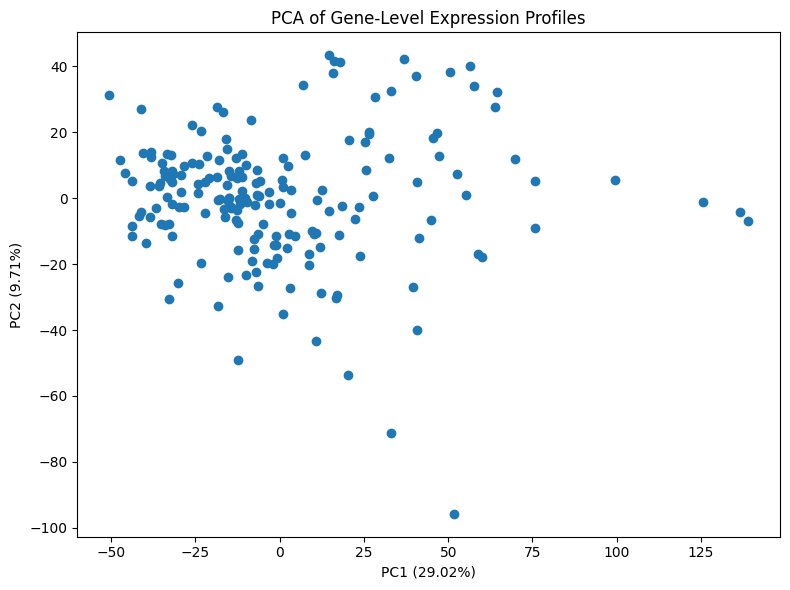

In [74]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_result[:, 0],
    X_pca_result[:, 1]
)

plt.xlabel(f"PC1 ({explained_variance[0] * 100:.2f}%)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.2f}%)")
plt.title("PCA of Gene-Level Expression Profiles")

plt.tight_layout()
plt.show()

In [75]:
pca_metadata = metadata_clean.set_index("sample_id").loc[
    gene_expression_log2.columns
]

pca_metadata[["group", "gender"]].head()

,group,gender
GSM650655,ASD,male
GSM650656,ASD,male
GSM650657,Control,male
GSM650658,ASD,male
GSM650659,ASD,male


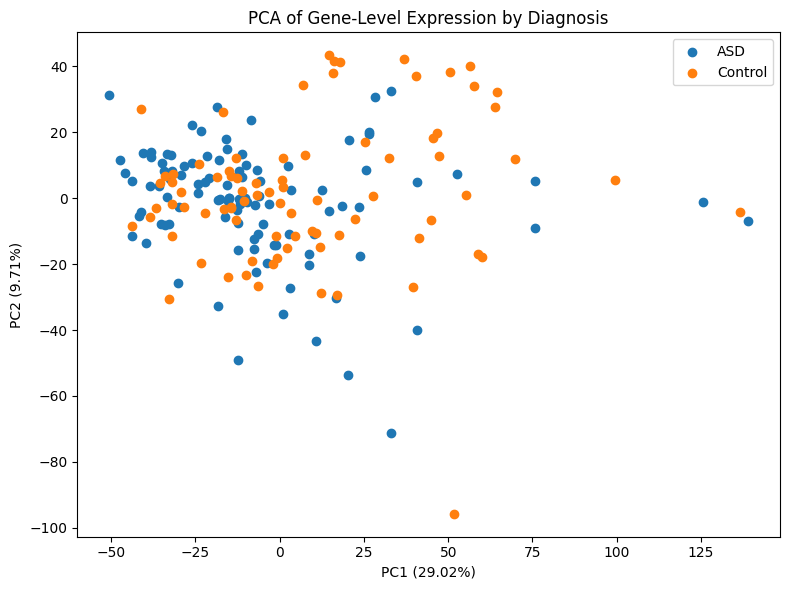

In [76]:
plt.figure(figsize=(8, 6))

for group in pca_metadata["group"].unique():
    mask = pca_metadata["group"] == group
    
    plt.scatter(
        X_pca_result[mask, 0],
        X_pca_result[mask, 1],
        label=group
    )

plt.xlabel(f"PC1 ({explained_variance[0] * 100:.2f}%)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.2f}%)")
plt.title("PCA of Gene-Level Expression by Diagnosis")
plt.legend()

plt.tight_layout()
plt.show()

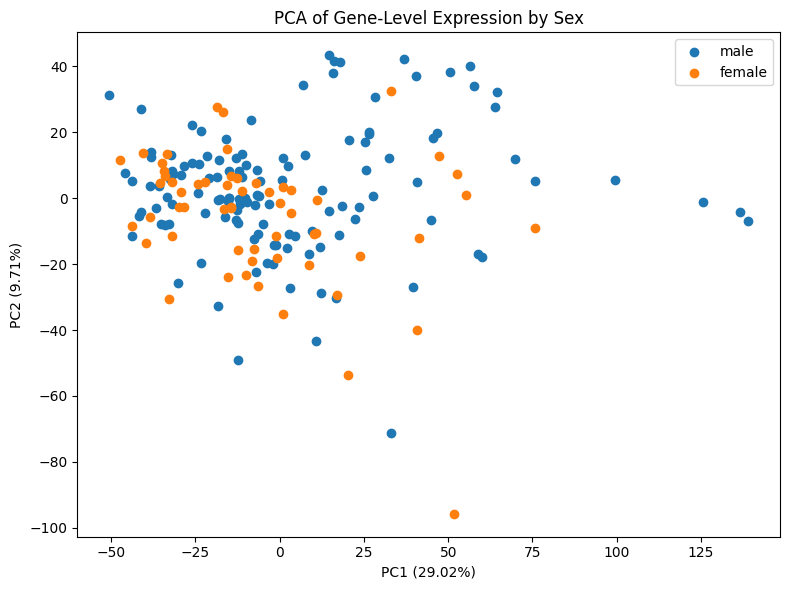

In [77]:
plt.figure(figsize=(8, 6))

for gender in pca_metadata["gender"].unique():
    mask = pca_metadata["gender"] == gender
    
    plt.scatter(
        X_pca_result[mask, 0],
        X_pca_result[mask, 1],
        label=gender
    )

plt.xlabel(f"PC1 ({explained_variance[0] * 100:.2f}%)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.2f}%)")
plt.title("PCA of Gene-Level Expression by Sex")
plt.legend()

plt.tight_layout()
plt.show()

In [78]:
from scipy.spatial.distance import euclidean

# Use the first 5 principal components
pca_coordinates = X_pca_result[:, :5]

pca_distance = np.sqrt(
    np.sum(
        (pca_coordinates - pca_coordinates.mean(axis=0)) ** 2,
        axis=1
    )
)

pca_outlier_check = pd.DataFrame({
    "sample_id": gene_expression_log2.columns,
    "PC_distance": pca_distance
})

pca_outlier_check = pca_outlier_check.sort_values(
    "PC_distance",
    ascending=False
)

pca_outlier_check.head(10)

,sample_id,PC_distance
120,GSM650830,142.957423
114,GSM650824,140.975806
68,GSM650725,130.536033
93,GSM650766,121.158377
124,GSM650834,105.599392
175,GSM650931,91.750124
182,GSM650968,88.409567
144,GSM650854,88.228569
176,GSM650944,87.808830
181,GSM650959,85.150994


In [79]:
print("PCA distance summary:")
print(pca_outlier_check["PC_distance"].describe())

PCA distance summary:
count    186.000000
mean      41.417200
std       23.108387
min        9.510356
25%       26.745317
50%       35.547518
75%       50.325612
max      142.957423
Name: PC_distance, dtype: float64


In [80]:
pca_outlier_check = pca_outlier_check.merge(
    metadata_clean[["sample_id", "group", "gender", "age_months"]],
    on="sample_id",
    how="left"
)

pca_outlier_check.head(10)

,sample_id,PC_distance,group,gender,age_months
0,GSM650830,142.957423,ASD,male,36
1,GSM650824,140.975806,Control,male,176
2,GSM650725,130.536033,ASD,male,132
3,GSM650766,121.158377,Control,female,148
4,GSM650834,105.599392,Control,male,36
5,GSM650931,91.750124,Control,male,143
6,GSM650968,88.409567,Control,male,51
7,GSM650854,88.228569,ASD,male,77
8,GSM650944,87.808830,Control,male,85
9,GSM650959,85.150994,Control,male,28


In [81]:
pca_analysis = pd.DataFrame(
    X_pca_result[:, :5],
    index=gene_expression_log2.columns,
    columns=[f"PC{i}" for i in range(1, 6)]
)

pca_analysis = pca_analysis.join(
    metadata_clean.set_index("sample_id")[[
        "group",
        "gender",
        "age_months"
    ]]
)

pca_analysis.head()

,PC1,PC2,PC3,PC4,PC5,group,gender,age_months
GSM650655,-34.081961,-8.064259,-0.920088,12.546233,4.696446,ASD,male,156
GSM650656,-32.678222,-7.883331,12.394930,37.786926,-32.103544,ASD,male,168
GSM650657,58.864835,-16.920493,-1.850296,-5.752370,9.076923,Control,male,228
GSM650658,25.637870,8.392644,7.956647,-0.087970,15.219638,ASD,male,60
GSM650659,-3.031544,-1.753031,14.273880,14.144165,-0.581959,ASD,male,36


In [82]:
age_correlations = pca_analysis[
    ["PC1", "PC2", "PC3", "PC4", "PC5"]
].corrwith(
    pca_analysis["age_months"]
)

print("Correlation between age and principal components:")
print(age_correlations)

Correlation between age and principal components:
PC1    0.041248
PC2   -0.284631
PC3    0.013977
PC4   -0.128717
PC5    0.361388
dtype: float64


In [83]:
from scipy.stats import mannwhitneyu

for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
    
    asd = pca_analysis.loc[
        pca_analysis["group"] == "ASD", pc
    ]
    
    control = pca_analysis.loc[
        pca_analysis["group"] == "Control", pc
    ]
    
    female = pca_analysis.loc[
        pca_analysis["gender"] == "female", pc
    ]
    
    male = pca_analysis.loc[
        pca_analysis["gender"] == "male", pc
    ]
    
    _, p_group = mannwhitneyu(
        asd,
        control,
        alternative="two-sided"
    )
    
    _, p_sex = mannwhitneyu(
        female,
        male,
        alternative="two-sided"
    )
    
    print(
        f"{pc}: "
        f"ASD vs Control p={p_group:.4g}, "
        f"Female vs Male p={p_sex:.4g}"
    )

PC1: ASD vs Control p=0.0005909, Female vs Male p=0.1777
PC2: ASD vs Control p=0.7204, Female vs Male p=0.0104
PC3: ASD vs Control p=0.03672, Female vs Male p=0.4213
PC4: ASD vs Control p=0.6439, Female vs Male p=0.1684
PC5: ASD vs Control p=0.5201, Female vs Male p=0.4029
